In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('Libraries loaded ✅')

Libraries loaded ✅


In [3]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# These are the base models — each one looks at the data differently
# The meta-model then learns how to best combine their predictions
base_models = [
    ('lr',  LogisticRegression(max_iter=500, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)),
    ('gb',  GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                        learning_rate=0.05, random_state=42)),
    ('svc', SVC(probability=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
]

print('Base models defined ✅')

Base models defined ✅


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── Load Data ──────────────────────────────────────────────
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

if 'Survived' in test.columns:
    test = test.drop(columns=['Survived'])

test_ids = test['PassengerId'].copy()
dfs = [train, test]

# ── Feature Engineering ────────────────────────────────────
for df in dfs:
    # Title
    df['Title'] = df['Name'].str.extract(r',\s*([^.]+)\.', expand=False).str.strip()
    rare = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
    df['Title'] = df['Title'].replace(rare, 'Rare')
    df['Title'] = df['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})

    # Family
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
    df['SmallFamily']= ((df['FamilySize'] >= 2) & (df['FamilySize'] <= 4)).astype(int)
    df['LargeFamily']= (df['FamilySize'] >= 5).astype(int)

    # Cabin
    df['HasCabin'] = df['Cabin'].notna().astype(int)

# ── Fill Missing Values ────────────────────────────────────
age_medians  = train.groupby('Title')['Age'].median()
fallback_age = age_medians.get('Rare', age_medians.median())

for df in dfs:
    df['Age'] = df.apply(
        lambda row: age_medians.get(row['Title'], fallback_age)
        if pd.isnull(row['Age']) else row['Age'], axis=1)

    df['Fare'] = df.groupby('Pclass')['Fare'].transform(
        lambda x: x.fillna(x.median()))

    df['Embarked'] = df['Embarked'].fillna(train['Embarked'].mode()[0])

    df['AgeBand']  = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                            labels=[0,1,2,3,4]).astype(int)
    df['FareBand'] = pd.qcut(df['Fare'], q=4,
                             labels=[0,1,2,3]).astype(int)

# ── New Features for Approach 3 ────────────────────────────
for df in dfs:
    df['FarePerPerson'] = df['Fare'] / df['FamilySize']
    df['IsChild']       = (df['Age'] < 12).astype(int)
    df['IsSenior']      = (df['Age'] > 60).astype(int)
    df['WomanOrChild']  = ((df['Sex'] == 'female') | (df['Age'] < 12)).astype(int)
    df['Pclass_Sex']    = df['Pclass'] * (df['Sex'] == 'male').astype(int)

# ── Encode Categoricals ────────────────────────────────────
le_title = LabelEncoder()
le_title.fit(pd.concat([train['Title'], test['Title']]))
train['Title'] = le_title.transform(train['Title'])
test['Title']  = le_title.transform(test['Title'])

le_sex = LabelEncoder()
le_sex.fit(train['Sex'])
train['Sex'] = le_sex.transform(train['Sex'])
test['Sex']  = le_sex.transform(test['Sex'])

le_emb = LabelEncoder()
le_emb.fit(train['Embarked'])
train['Embarked'] = le_emb.transform(train['Embarked'])
test['Embarked']  = le_emb.transform(test['Embarked'])

# ── Feature Matrix ─────────────────────────────────────────
FEATURES = ['Pclass', 'Sex', 'AgeBand', 'FareBand', 'FarePerPerson',
            'Embarked', 'Title', 'FamilySize', 'IsAlone', 'HasCabin',
            'IsChild', 'IsSenior', 'WomanOrChild', 'Pclass_Sex',
            'LargeFamily', 'SmallFamily']

X      = train[FEATURES]
y      = train['Survived']
X_test = test[FEATURES]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Everything ready!')
print(f'   X shape       : {X.shape}')
print(f'   X_test shape  : {X_test.shape}')
print(f'   Features      : {len(FEATURES)}')
print(f'   Nulls in X    : {X.isnull().sum().sum()}')
print(f'   Nulls in Xtest: {X_test.isnull().sum().sum()}')

Everything ready!
   X shape       : (891, 16)
   X_test shape  : (418, 16)
   Features      : 16
   Nulls in X    : 0
   Nulls in Xtest: 0


In [5]:
# Re-run this on your existing train/test dataframes
for df in [train, test]:

    # Fare per person (shared tickets skew the fare)
    df['FarePerPerson'] = df['Fare'] / df['FamilySize']

    # Child flag (children had priority on lifeboats)
    df['IsChild'] = (df['Age'] < 12).astype(int)

    # Senior flag
    df['IsSenior'] = (df['Age'] > 60).astype(int)

    # Woman or child (the "women and children first" rule)
    df['WomanOrChild'] = ((df['Sex'] == 0) | (df['Age'] < 12)).astype(int)

    # Pclass and Sex interaction (1st class women survived at ~97%)
    df['Pclass_Sex'] = df['Pclass'] * df['Sex']

    # Large family flag (very large families had lower survival)
    df['LargeFamily'] = (df['FamilySize'] >= 5).astype(int)

    # Small family flag (2-4 members did better than alone or large)
    df['SmallFamily'] = ((df['FamilySize'] >= 2) & (df['FamilySize'] <= 4)).astype(int)

print('New features added ✅')

# Update feature list
FEATURES = ['Pclass', 'Sex', 'AgeBand', 'FareBand', 'FarePerPerson',
            'Embarked', 'Title', 'FamilySize', 'IsAlone', 'HasCabin',
            'IsChild', 'IsSenior', 'WomanOrChild', 'Pclass_Sex',
            'LargeFamily', 'SmallFamily']

X      = train[FEATURES]
y      = train['Survived']
X_test = test[FEATURES]

print(f'Feature count: {len(FEATURES)}')
print(f'X shape: {X.shape}')

New features added ✅
Feature count: 16
X shape: (891, 16)


In [6]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.02,
    subsample=0.8,           # use 80% of rows per tree
    colsample_bytree=0.8,    # use 80% of features per tree
    min_child_weight=1,
    gamma=0,
    reg_alpha=0.1,           # L1 regularisation
    reg_lambda=1.0,          # L2 regularisation
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

xgb_scores = cross_val_score(xgb, X, y, cv=cv, scoring='accuracy')
print(f'XGBoost CV Accuracy: {xgb_scores.mean():.4f} ± {xgb_scores.std():.4f}')

XGBoost CV Accuracy: 0.8395 ± 0.0185


In [7]:
lgbm = LGBMClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1
)

lgbm_scores = cross_val_score(lgbm, X, y, cv=cv, scoring='accuracy')
print(f'LightGBM CV Accuracy: {lgbm_scores.mean():.4f} ± {lgbm_scores.std():.4f}')

LightGBM CV Accuracy: 0.8350 ± 0.0124


In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth'        : [2, 3, 4],
    'learning_rate'    : [0.01, 0.02, 0.05],
    'n_estimators'     : [300, 500],
    'subsample'        : [0.7, 0.8],
    'colsample_bytree' : [0.7, 0.8],
}

grid_search = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print(f'\nBest Parameters : {grid_search.best_params_}')
print(f'Best CV Score   : {grid_search.best_score_:.4f}')

best_xgb = grid_search.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Parameters : {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.7}
Best CV Score   : 0.8428


In [9]:
param_grid_lgbm = {
    'max_depth'        : [2, 3, 4],
    'learning_rate'    : [0.01, 0.02, 0.05],
    'n_estimators'     : [300, 500],
    'subsample'        : [0.7, 0.8],
    'colsample_bytree' : [0.7, 0.8],
}

grid_search_lgbm = GridSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_grid_lgbm,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_lgbm.fit(X, y)

print(f'\nBest Parameters : {grid_search_lgbm.best_params_}')
print(f'Best CV Score   : {grid_search_lgbm.best_score_:.4f}')

best_lgbm = grid_search_lgbm.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Parameters : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.7}
Best CV Score   : 0.8474


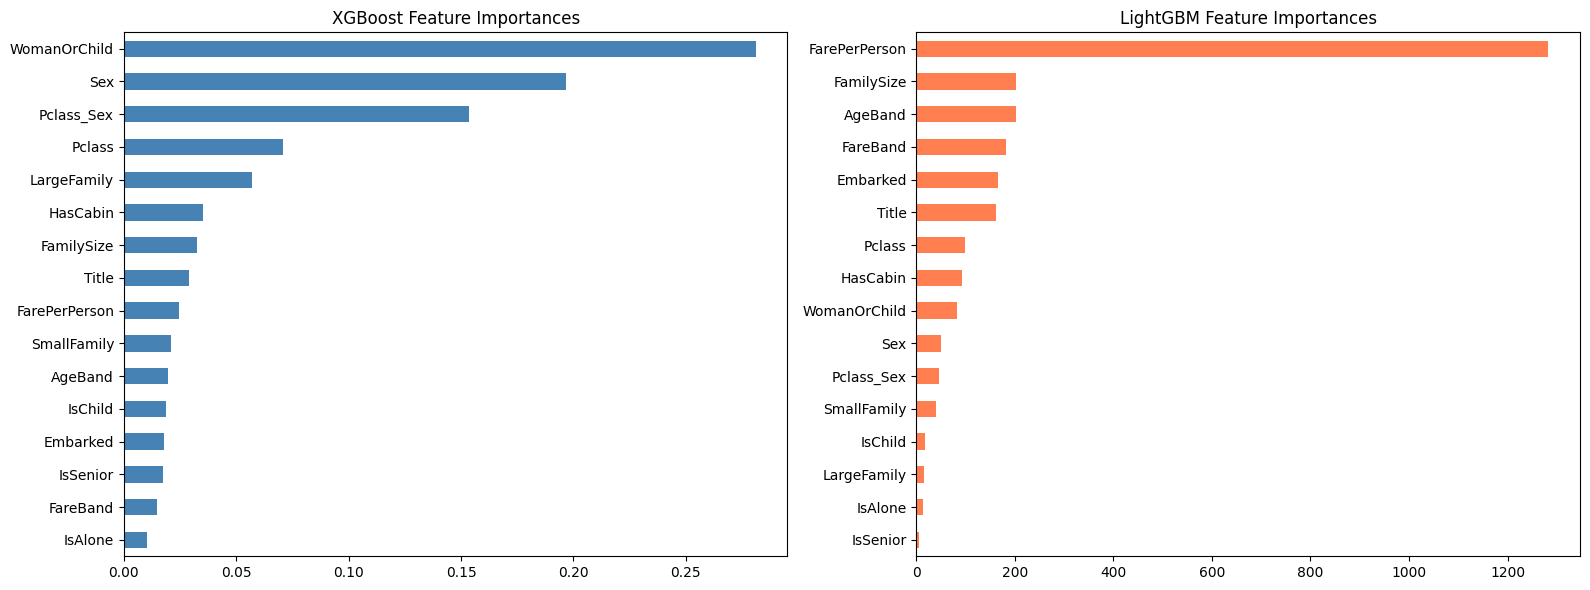

In [10]:
# Train both on full data to inspect feature importances
best_xgb.fit(X, y)
best_lgbm.fit(X, y)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost importances
pd.Series(best_xgb.feature_importances_, index=FEATURES)\
  .sort_values()\
  .plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('XGBoost Feature Importances')

# LightGBM importances
pd.Series(best_lgbm.feature_importances_, index=FEATURES)\
  .sort_values()\
  .plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('LightGBM Feature Importances')

plt.tight_layout()
plt.show()

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=500, max_depth=5, random_state=42)
rf.fit(X, y)

# Get predicted probabilities from each model
xgb_proba  = best_xgb.predict_proba(X_test)[:, 1]
lgbm_proba = best_lgbm.predict_proba(X_test)[:, 1]
rf_proba   = rf.predict_proba(X_test)[:, 1]

# Weighted average — give more weight to better models
# Adjust weights based on your CV scores
avg_proba = (0.4 * xgb_proba) + (0.4 * lgbm_proba) + (0.2 * rf_proba)

final_predictions = (avg_proba >= 0.5).astype(int)

submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived'   : final_predictions
})

submission.to_csv('submission.csv', index=False)
print('submission.csv saved ✅')
print(f'Predicted {final_predictions.sum()} survivors out of {len(final_predictions)}')
submission.head(10)

submission.csv saved ✅
Predicted 154 survivors out of 418


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [12]:
all_models = {
    'Gradient Boosting (sklearn)' : GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                                                learning_rate=0.05, random_state=42),
    'XGBoost (tuned)'             : best_xgb,
    'LightGBM (tuned)'            : best_lgbm,
    'Random Forest'               : RandomForestClassifier(n_estimators=500, max_depth=5, random_state=42),
}

print(f'{"Model":<30}  {"Mean CV Accuracy":>16}  {"Std":>8}')
print('-' * 62)

for name, model in all_models.items():
    s = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    print(f'{name:<30}  {s.mean():.4f}            ±{s.std():.4f}')

Model                           Mean CV Accuracy       Std
--------------------------------------------------------------
Gradient Boosting (sklearn)     0.8339            ±0.0178
XGBoost (tuned)                 0.8428            ±0.0203
LightGBM (tuned)                0.8474            ±0.0067
Random Forest                   0.8316            ±0.0108
